# Online Retail II — 퍼널, 코호트 & AARRR 분석

**데이터셋**: [Online Retail II (UCI)](https://archive.ics.uci.edu/dataset/502/online+retail+ii) — 영국 온라인 리테일 실거래 데이터 (~100만 건, 2009.12 ~ 2011.12)

**목표**: 고객의 구매 행동을 여러 관점에서 분석하여, "어디서 고객이 빠지는지", "언제 다시 오는지", "돈은 얼마나 쓰는지" 파악하고, 이를 바탕으로 실행 가능한 비즈니스 제안을 도출한다.

## 목차
1. [데이터 로딩 & 전처리](#1-데이터-로딩--전처리)
2. [탐색적 데이터 분석 (EDA)](#2-탐색적-데이터-분석-eda)
3. [고객 인게이지먼트 퍼널](#3-고객-인게이지먼트-퍼널)
4. [코호트 분석](#4-코호트-분석)
5. [AARRR 해적 지표](#5-aarrr-해적-지표)
6. [핵심 인사이트 & 제안](#6-핵심-인사이트--제안)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

# 한글 폰트 설정 (Windows)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['figure.figsize'] = (12, 5)

IMAGES_DIR = Path('../images')
IMAGES_DIR.mkdir(exist_ok=True)

---
## 1. 데이터 로딩 & 전처리

> **이게 뭔데?**  
> 분석에 쓸 원본 데이터를 불러오고, 쓸 수 없는 데이터(빈 값, 취소 주문 등)를 제거하는 과정이다.  
> 요리하기 전에 재료를 씻고 다듬는 것과 같다.
>
> **왜 하는 건데?**  
> 더러운 데이터로 분석하면 결과도 엉망이 된다. "Garbage In, Garbage Out" 이라는 말이 있을 정도로 데이터 정제는 분석의 기본 중 기본이다.

In [2]:
# 엑셀 파일의 두 시트를 각각 읽어서 하나로 합침
sheet1 = pd.read_excel('../data/online_retail_II.xlsx', sheet_name='Year 2009-2010')
sheet2 = pd.read_excel('../data/online_retail_II.xlsx', sheet_name='Year 2010-2011')
raw = pd.concat([sheet1, sheet2], ignore_index=True)

print(f'원본 데이터 크기: {raw.shape[0]:,}행 x {raw.shape[1]}열')
raw.head()

원본 데이터 크기: 1,067,371행 x 8열


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [3]:
print('--- 컬럼별 데이터 타입 ---')
print(raw.dtypes)
print(f'\n--- 결측값 (비어있는 값) ---')
print(raw.isnull().sum())
print(f'\nCustomer ID 결측 비율: {raw["Customer ID"].isnull().mean():.1%}')
print('→ 약 4건 중 1건은 고객 정보가 없다. 이런 행은 고객 분석에 쓸 수 없으므로 제거해야 한다.')

--- 컬럼별 데이터 타입 ---
Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
Price                 float64
Customer ID           float64
Country                   str
dtype: object

--- 결측값 (비어있는 값) ---


Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

Customer ID 결측 비율: 22.8%
→ 약 4건 중 1건은 고객 정보가 없다. 이런 행은 고객 분석에 쓸 수 없으므로 제거해야 한다.


In [4]:
df = raw.copy()

# 1단계: Customer ID가 비어있는 행 제거 (누가 샀는지 모르면 분석 불가)
df = df.dropna(subset=['Customer ID'])

# 2단계: 취소 주문 제거 (Invoice가 'C'로 시작하면 취소 건)
df = df[~df['Invoice'].astype(str).str.startswith('C')]

# 3단계: 수량이나 가격이 0 이하인 비정상 데이터 제거
df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]

# 4단계: 파생 변수 생성
df['Revenue'] = df['Quantity'] * df['Price']           # 매출 = 수량 x 단가
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['InvoiceMonth'] = df['InvoiceDate'].dt.to_period('M')           # 주문 월 (Period)
df['InvoiceYearMonth'] = df['InvoiceDate'].dt.to_period('M').dt.to_timestamp()  # 주문 월 (Timestamp)
df['Customer ID'] = df['Customer ID'].astype(int)

print(f'정제 후 데이터 크기: {df.shape[0]:,}행')
print(f'기간: {df["InvoiceDate"].min().date()} ~ {df["InvoiceDate"].max().date()}')
print(f'고유 고객 수: {df["Customer ID"].nunique():,}명')
print(f'고유 주문 수: {df["Invoice"].nunique():,}건')
print(f'총 매출: £{df["Revenue"].sum():,.0f}')

정제 후 데이터 크기: 805,549행
기간: 2009-12-01 ~ 2011-12-09
고유 고객 수: 5,878명
고유 주문 수: 36,969건
총 매출: £17,743,429


---
## 2. 탐색적 데이터 분석 (EDA)

> **이게 뭔데?**  
> EDA(Exploratory Data Analysis)는 데이터를 처음 만났을 때 "대충 어떻게 생겼는지" 눈으로 확인하는 과정이다.  
> 그래프를 그려서 전체적인 패턴, 이상한 점, 큰 흐름을 먼저 파악한다.
>
> **왜 하는 건데?**  
> 숫자만 보면 감이 안 온다. 그래프로 시각화해야 "매출이 11월에 확 뛰네", "한 번만 사고 안 오는 사람이 엄청 많네" 같은 패턴이 한눈에 보인다.  
> 깊은 분석(퍼널, 코호트)으로 들어가기 전에 데이터의 큰 그림을 잡는 단계이다.

### 2.1 월별 매출 추이

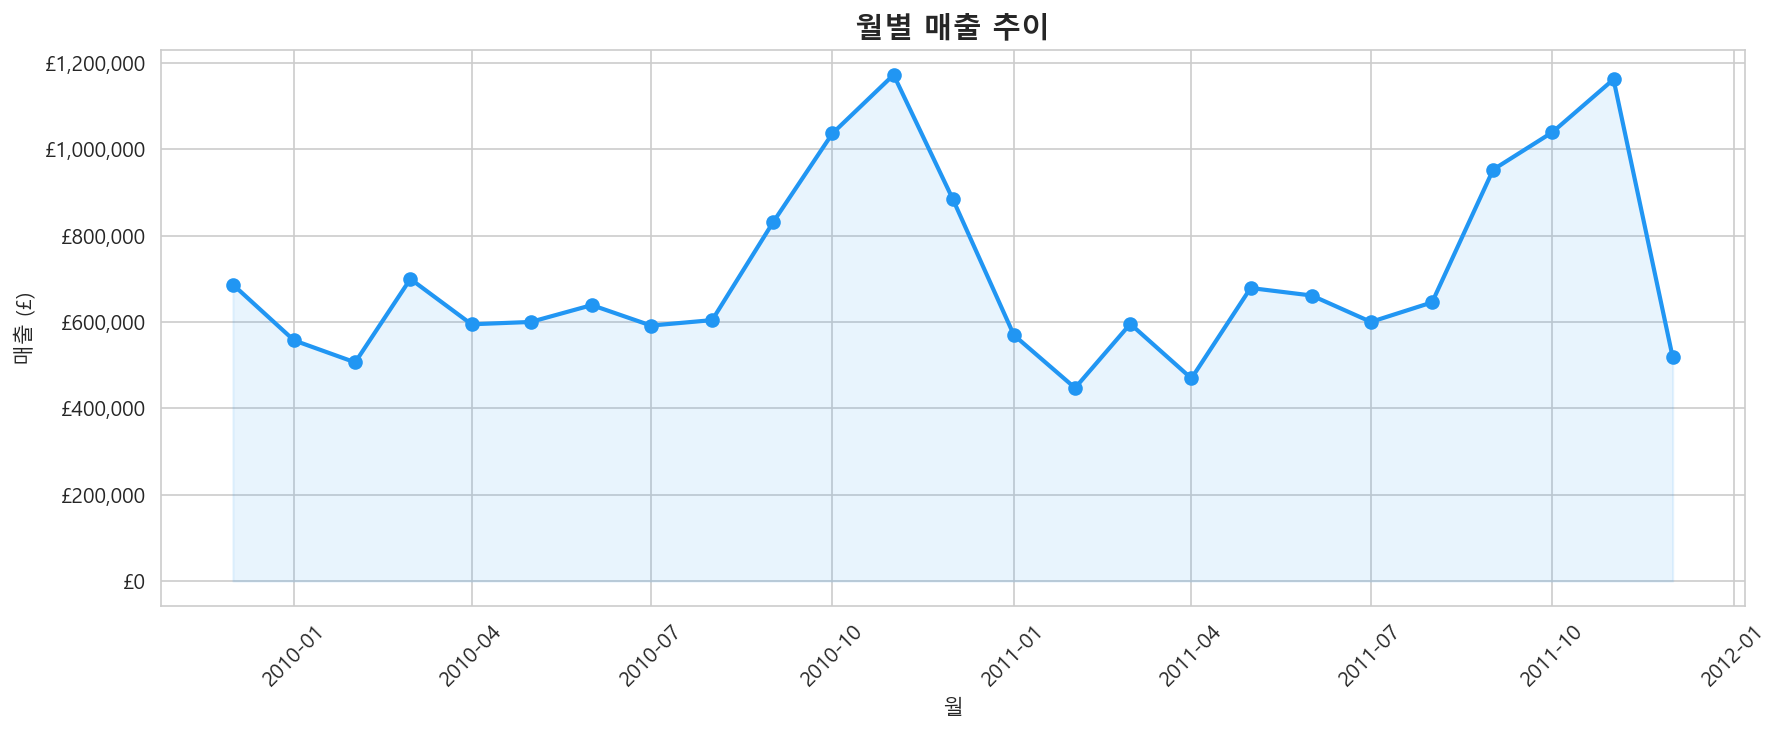

In [5]:
monthly_revenue = df.groupby('InvoiceYearMonth')['Revenue'].sum()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(monthly_revenue.index, monthly_revenue.values, marker='o', linewidth=2, color='#2196F3')
ax.fill_between(monthly_revenue.index, monthly_revenue.values, alpha=0.1, color='#2196F3')
ax.set_title('월별 매출 추이', fontsize=14, fontweight='bold')
ax.set_xlabel('월')
ax.set_ylabel('매출 (£)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(IMAGES_DIR / '01_monthly_revenue.png', bbox_inches='tight')
plt.show()

### 2.2 월별 고유 고객 수

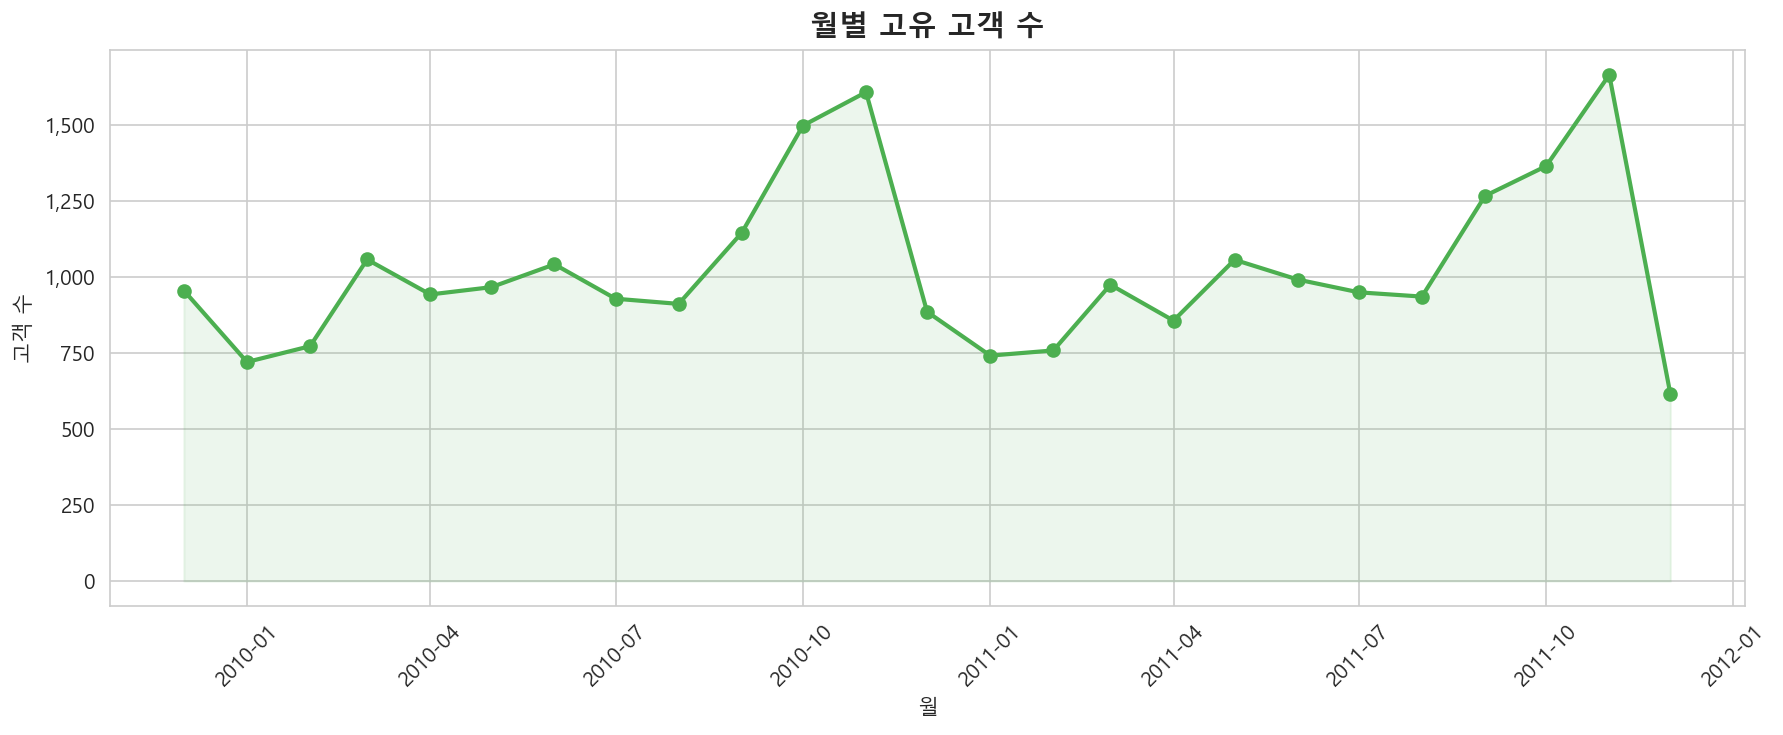

In [6]:
monthly_customers = df.groupby('InvoiceYearMonth')['Customer ID'].nunique()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(monthly_customers.index, monthly_customers.values, marker='o', linewidth=2, color='#4CAF50')
ax.fill_between(monthly_customers.index, monthly_customers.values, alpha=0.1, color='#4CAF50')
ax.set_title('월별 고유 고객 수', fontsize=14, fontweight='bold')
ax.set_xlabel('월')
ax.set_ylabel('고객 수')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(IMAGES_DIR / '02_monthly_customers.png', bbox_inches='tight')
plt.show()

### 2.3 국가별 매출 Top 10

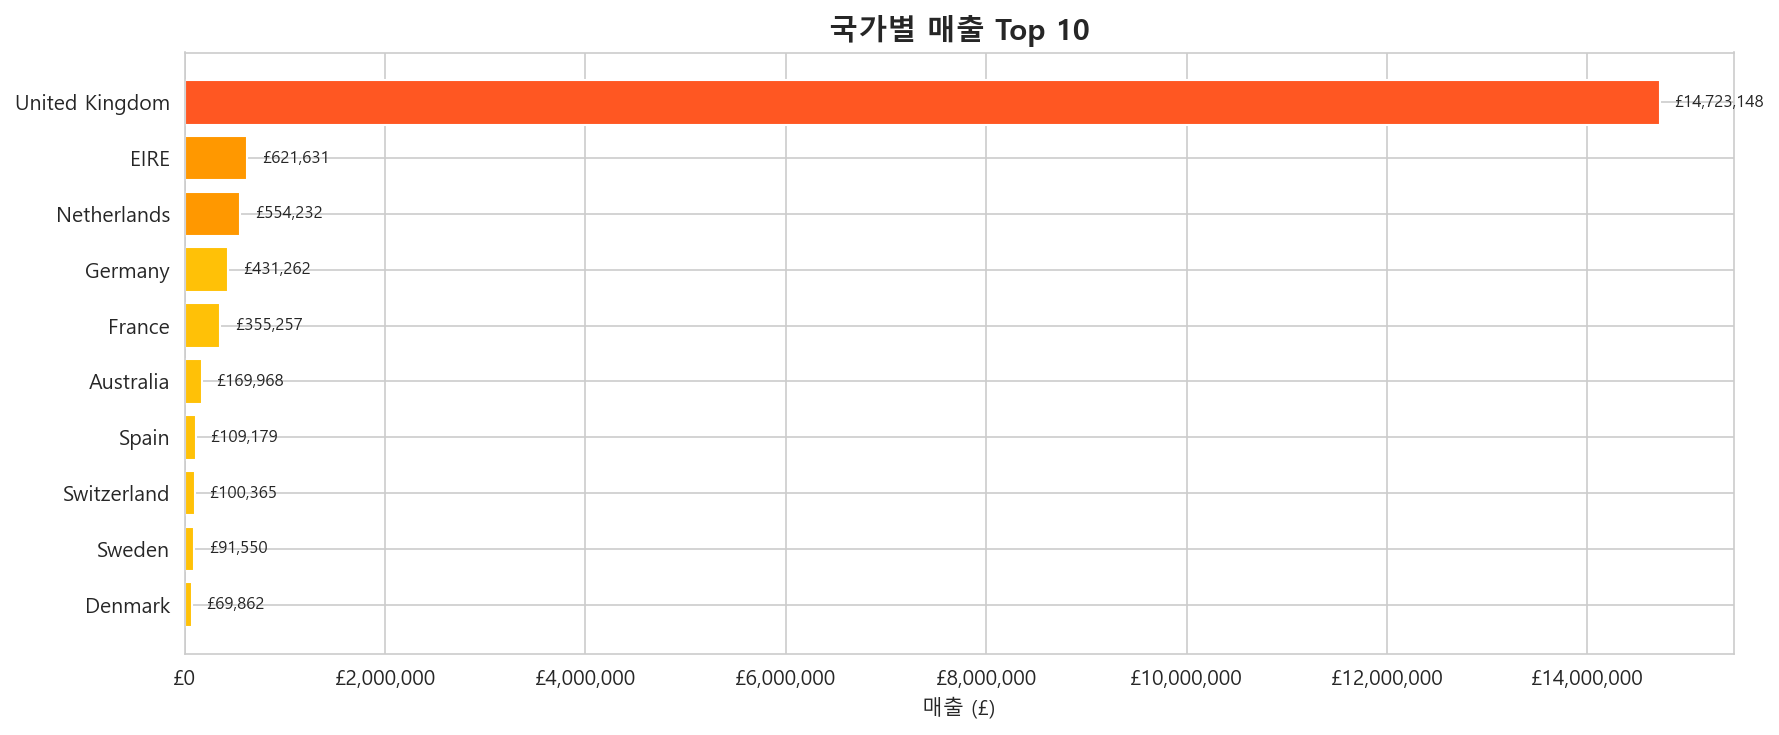

영국(UK)이 전체 매출에서 차지하는 비중: 83.0%


In [7]:
country_revenue = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False)
top10 = country_revenue.head(10)

fig, ax = plt.subplots(figsize=(12, 5))
colors = ['#FF5722' if i == 0 else '#FF9800' if i < 3 else '#FFC107' for i in range(len(top10))]
bars = ax.barh(top10.index[::-1], top10.values[::-1], color=colors[::-1], edgecolor='white')
ax.set_title('국가별 매출 Top 10', fontsize=14, fontweight='bold')
ax.set_xlabel('매출 (£)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))

for bar, val in zip(bars, top10.values[::-1]):
    ax.text(val + country_revenue.max() * 0.01, bar.get_y() + bar.get_height() / 2,
            f'£{val:,.0f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig(IMAGES_DIR / '03_top10_countries.png', bbox_inches='tight')
plt.show()

print(f'영국(UK)이 전체 매출에서 차지하는 비중: {country_revenue["United Kingdom"] / country_revenue.sum():.1%}')

### 2.4 고객당 주문 횟수 분포

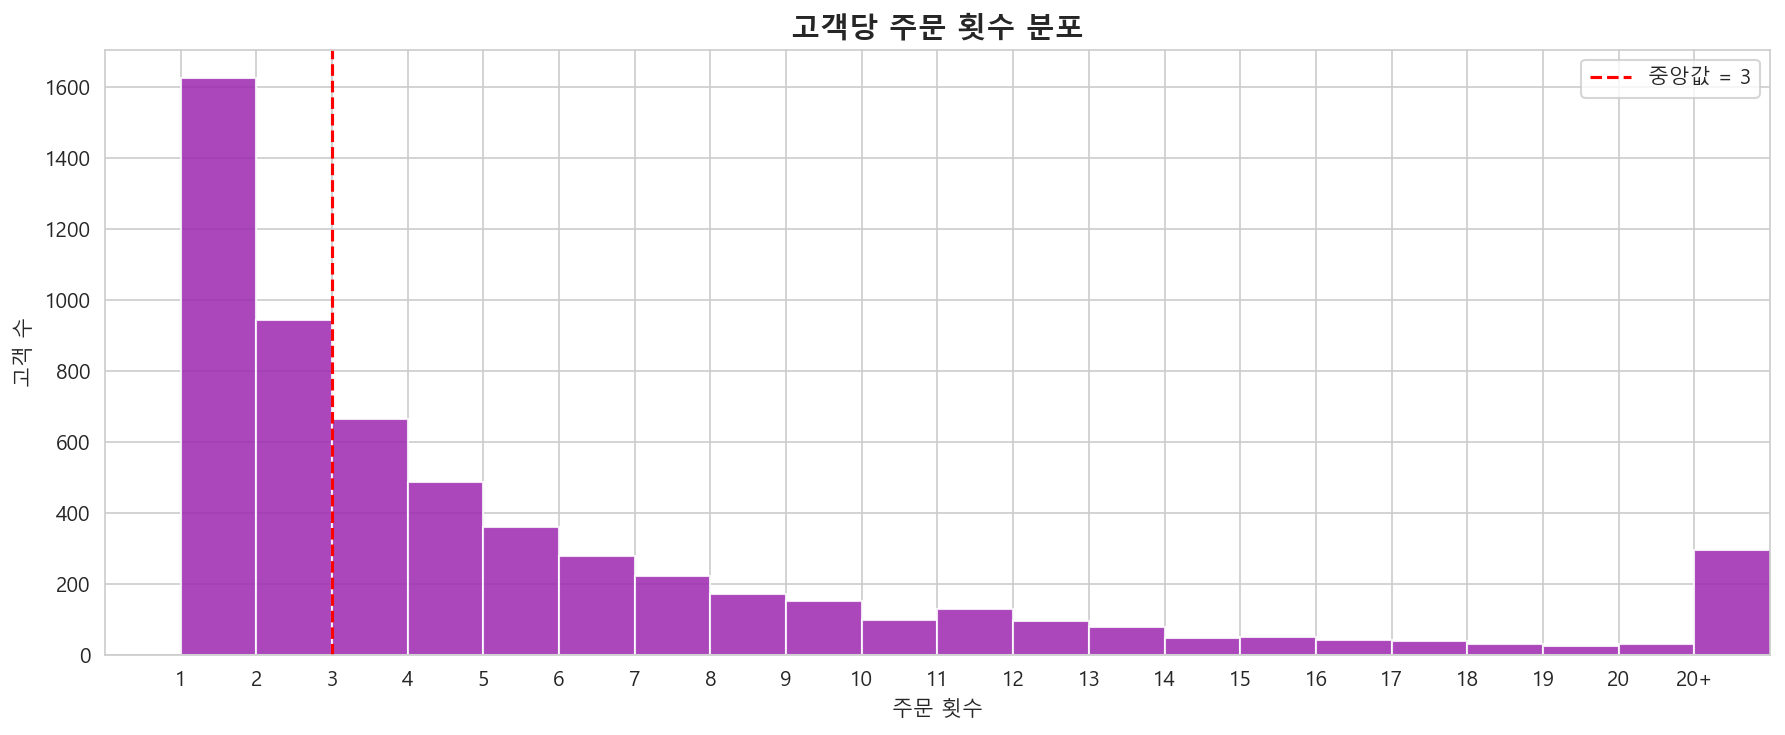

평균 주문 횟수: 6.3회
중앙값 주문 횟수: 3회
딱 1번만 주문한 고객: 1,623명 (27.6%)


In [8]:
customer_orders = df.groupby('Customer ID')['Invoice'].nunique()

fig, ax = plt.subplots(figsize=(12, 5))
bins = list(range(1, 22)) + [customer_orders.max() + 1]
ax.hist(customer_orders.values, bins=bins, color='#9C27B0', edgecolor='white', alpha=0.85)
ax.set_title('고객당 주문 횟수 분포', fontsize=14, fontweight='bold')
ax.set_xlabel('주문 횟수')
ax.set_ylabel('고객 수')
ax.set_xlim(0, 22)
ax.set_xticks(range(1, 22))
labels = [str(i) for i in range(1, 21)] + ['20+']
ax.set_xticklabels(labels)

median_orders = customer_orders.median()
ax.axvline(median_orders, color='red', linestyle='--', linewidth=1.5, label=f'중앙값 = {median_orders:.0f}')
ax.legend()
plt.tight_layout()
plt.savefig(IMAGES_DIR / '04_order_frequency.png', bbox_inches='tight')
plt.show()

print(f'평균 주문 횟수: {customer_orders.mean():.1f}회')
print(f'중앙값 주문 횟수: {customer_orders.median():.0f}회')
print(f'딱 1번만 주문한 고객: {(customer_orders == 1).sum():,}명 ({(customer_orders == 1).mean():.1%})')

### 2.5 매출 집중도 (파레토 곡선)

> **파레토 법칙**: "전체 결과의 80%는 전체 원인의 20%에서 나온다"는 경험 법칙이다.  
> 여기서는 "전체 매출의 80%를 상위 몇 %의 고객이 만들어내는가?"를 확인한다.

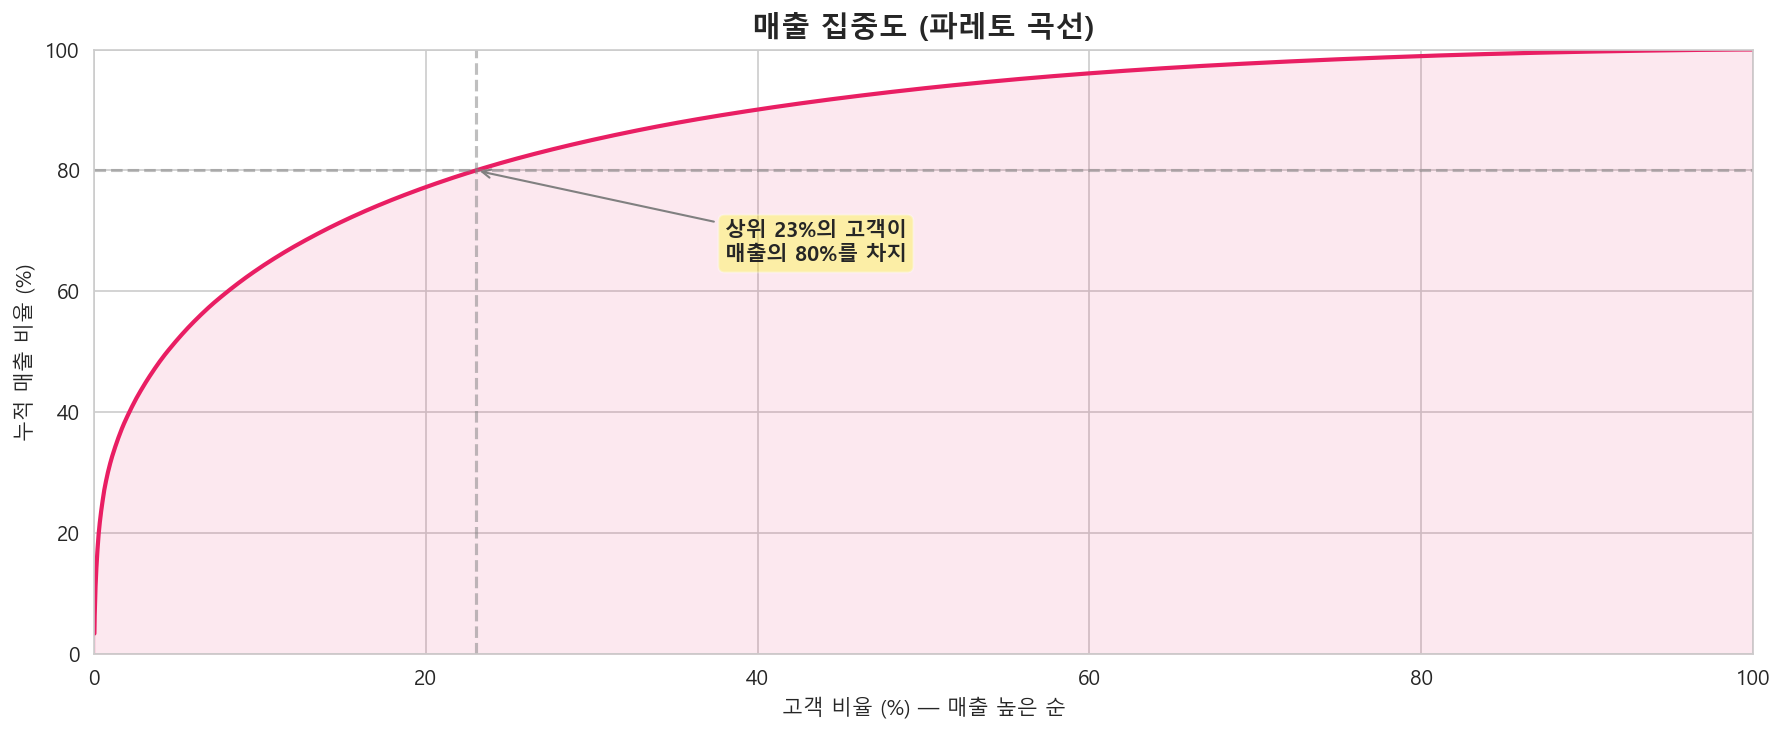

In [9]:
customer_revenue = df.groupby('Customer ID')['Revenue'].sum().sort_values(ascending=False)
cumulative_pct = customer_revenue.cumsum() / customer_revenue.sum() * 100
customer_pct = np.arange(1, len(cumulative_pct) + 1) / len(cumulative_pct) * 100

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(customer_pct, cumulative_pct.values, color='#E91E63', linewidth=2)
ax.fill_between(customer_pct, cumulative_pct.values, alpha=0.1, color='#E91E63')

# 매출 80% 지점 찾기
idx_80 = np.searchsorted(cumulative_pct.values, 80)
pct_80 = customer_pct[idx_80]
ax.axhline(80, color='gray', linestyle='--', alpha=0.5)
ax.axvline(pct_80, color='gray', linestyle='--', alpha=0.5)
ax.annotate(f'상위 {pct_80:.0f}%의 고객이\n매출의 80%를 차지',
            xy=(pct_80, 80), xytext=(pct_80 + 15, 65),
            fontsize=10, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='gray'),
            bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.3))

ax.set_title('매출 집중도 (파레토 곡선)', fontsize=14, fontweight='bold')
ax.set_xlabel('고객 비율 (%) — 매출 높은 순')
ax.set_ylabel('누적 매출 비율 (%)')
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
plt.tight_layout()
plt.savefig(IMAGES_DIR / '05_pareto.png', bbox_inches='tight')
plt.show()

---
## 3. 고객 인게이지먼트 퍼널

> **퍼널(Funnel)이 뭔데?**  
> 퍼널은 "깔때기"라는 뜻이다. 고객이 처음 들어와서 최종 목표(구매, 재구매, 충성 고객)까지 가는 과정을 단계별로 나눈 것이다.  
> 깔때기처럼 위는 넓고(많은 사람이 들어오고) 아래로 갈수록 좁아진다(점점 빠져나간다).
>
> 예를 들어 쇼핑몰이라면:  
> `사이트 방문 → 상품 클릭 → 장바구니 담기 → 결제 완료`  
> 이렇게 단계마다 몇 명이 남는지 보는 것이다.
>
> **왜 하는 건데?**  
> **"어디서 고객이 빠지는지"** 를 찾기 위해서다.  
> 전체 고객 5,878명 중 재구매하는 사람이 몇 명인지, 꾸준히 사는 사람이 몇 명인지 보면  
> "1회 구매 → 재구매 단계에서 27.6%가 이탈하는구나" 같은 병목(bottleneck)을 발견할 수 있다.  
> 이걸 알아야 "어디에 마케팅 비용을 쓸지" 판단할 수 있다.
>
> **이 데이터에서는?**  
> 웹 로그(방문, 클릭 등)가 없으므로 구매 데이터만으로 아래와 같이 퍼널을 정의한다:

| 단계 | 정의 | 쉽게 말하면 |
|---|---|---|
| 전체 고객 | 1회 이상 구매 | 한 번이라도 산 사람 |
| 재구매 고객 | 2회 이상 주문 | 두 번 이상 산 사람 |
| 정기 고객 | 3개월 이상 활동 | 꾸준히 사는 사람 |
| 고가치 고객 | 매출 상위 25% | 돈 많이 쓴 사람 |
| 충성 고가치 | 상위 25% AND 3개월 이상 | 돈도 많이 쓰고 꾸준한 사람 |

In [10]:
# 고객별 지표 계산
cust = df.groupby('Customer ID').agg(
    n_orders=('Invoice', 'nunique'),       # 주문 횟수
    n_months=('InvoiceMonth', 'nunique'),   # 활동 월 수
    total_revenue=('Revenue', 'sum')        # 총 매출
).reset_index()

revenue_75th = cust['total_revenue'].quantile(0.75)  # 상위 25% 기준선

funnel = {
    '전체 고객': len(cust),
    '재구매 고객 (2회+)': (cust['n_orders'] >= 2).sum(),
    '정기 고객 (3개월+)': (cust['n_months'] >= 3).sum(),
    '고가치 고객 (상위 25%)': (cust['total_revenue'] >= revenue_75th).sum(),
    '충성 고가치 고객': ((cust['total_revenue'] >= revenue_75th) & (cust['n_months'] >= 3)).sum()
}

funnel_df = pd.DataFrame(list(funnel.items()), columns=['단계', '고객 수'])
funnel_df['전체 대비 (%)'] = (funnel_df['고객 수'] / funnel_df['고객 수'].iloc[0] * 100).round(1)
funnel_df['전환율'] = ['-'] + [
    f"{funnel_df['고객 수'].iloc[i] / funnel_df['고객 수'].iloc[i-1] * 100:.1f}%"
    for i in range(1, len(funnel_df))
]

print(funnel_df.to_string(index=False))
print(f'\n→ 해석: 전체 고객의 {funnel_df["전체 대비 (%)"].iloc[-1]}%만이 "돈 많이 쓰고 + 꾸준히 오는" 충성 고객이다.')

             단계  고객 수  전체 대비 (%)   전환율
          전체 고객  5878      100.0     -
   재구매 고객 (2회+)  4255       72.4 72.4%
   정기 고객 (3개월+)  3030       51.5 71.2%
고가치 고객 (상위 25%)  1470       25.0 48.5%
      충성 고가치 고객  1404       23.9 95.5%

→ 해석: 전체 고객의 23.9%만이 "돈 많이 쓰고 + 꾸준히 오는" 충성 고객이다.


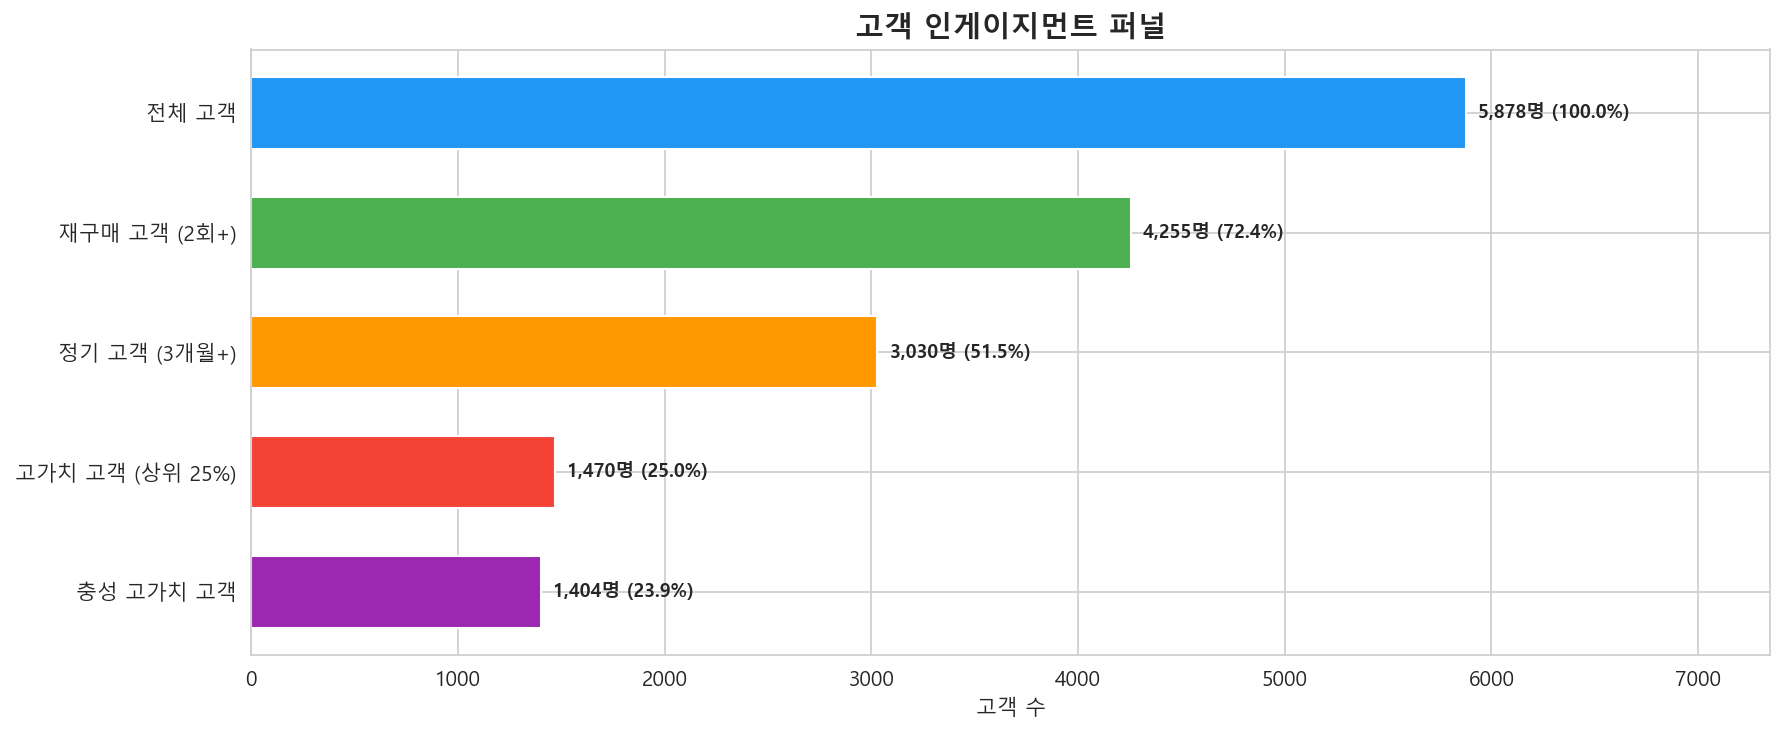

In [11]:
fig, ax = plt.subplots(figsize=(12, 5))

colors = ['#2196F3', '#4CAF50', '#FF9800', '#F44336', '#9C27B0']
y_pos = range(len(funnel_df) - 1, -1, -1)

bars = ax.barh(y_pos, funnel_df['고객 수'], color=colors, edgecolor='white', height=0.6)
ax.set_yticks(y_pos)
ax.set_yticklabels(funnel_df['단계'])
ax.set_title('고객 인게이지먼트 퍼널', fontsize=14, fontweight='bold')
ax.set_xlabel('고객 수')

for bar, customers, pct in zip(bars, funnel_df['고객 수'], funnel_df['전체 대비 (%)']):
    ax.text(bar.get_width() + funnel_df['고객 수'].max() * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f'{customers:,}명 ({pct}%)', va='center', fontsize=9, fontweight='bold')

ax.set_xlim(0, funnel_df['고객 수'].max() * 1.25)
plt.tight_layout()
plt.savefig(IMAGES_DIR / '06_funnel.png', bbox_inches='tight')
plt.show()

---
## 4. 코호트 분석

> **코호트(Cohort)가 뭔데?**  
> 코호트는 "같은 시기에 특정 경험을 공유한 집단"이라는 뜻이다.  
> 여기서는 **같은 달에 처음 구매한 고객 그룹**을 하나의 코호트로 묶는다.  
> 예: "2010년 1월에 처음 산 고객들" = 2010-01 코호트
>
> **왜 하는 건데?**  
> 단순히 "이번 달 재구매율이 30%" 라고만 보면, 이게 좋은 건지 나쁜 건지 모른다.  
> 코호트 분석을 하면 **"처음 산 후 1개월 뒤, 2개월 뒤, 3개월 뒤에 각각 몇 %가 다시 오는지"** 시간 흐름에 따라 추적할 수 있다.
>
> 이게 왜 중요하냐면:
> - "1월 코호트는 3개월 후에 25%가 남았는데, 6월 코호트는 15%밖에 안 남았네" → 6월에 뭔가 문제가 있었다
> - "모든 코호트에서 첫 달에 80%가 이탈하네" → 첫 구매 후 재구매 유도가 가장 시급한 과제
> - 이런 식으로 **어디서 고객이 빠지는지, 시간이 지나도 남는 고객이 얼마나 되는지** 정확히 파악할 수 있다.
>
> **리텐션 히트맵이 뭔데?**  
> 코호트별 잔존율(돌아오는 비율)을 색깔로 표현한 표다.  
> 빨간색이 진하면 = 많이 돌아옴, 연하면 = 적게 돌아옴.  
> 한눈에 "어느 코호트가 잘 남고, 어느 코호트가 빨리 빠지는지" 볼 수 있다.

In [12]:
# 각 고객의 첫 구매월 = 그 고객이 속하는 코호트
df['CohortMonth'] = df.groupby('Customer ID')['InvoiceYearMonth'].transform('min')

# 코호트 인덱스 = 첫 구매 이후 몇 개월째인지
df['CohortIndex'] = ((df['InvoiceYearMonth'].dt.year - df['CohortMonth'].dt.year) * 12 +
                      (df['InvoiceYearMonth'].dt.month - df['CohortMonth'].dt.month))

# 코호트 테이블: (코호트월, 경과월) 별 고유 고객 수
cohort_data = df.groupby(['CohortMonth', 'CohortIndex'])['Customer ID'].nunique().reset_index()
cohort_pivot = cohort_data.pivot(index='CohortMonth', columns='CohortIndex', values='Customer ID')

# 잔존율: 각 월의 고객 수를 첫 달(0개월) 고객 수로 나누기
cohort_size = cohort_pivot.iloc[:, 0]
retention = cohort_pivot.divide(cohort_size, axis=0) * 100

print(f'코호트 수: {len(retention)}개')
print(f'코호트 범위: {retention.index.min().strftime("%Y-%m")} ~ {retention.index.max().strftime("%Y-%m")}')

코호트 수: 25개
코호트 범위: 2009-12 ~ 2011-12


### 4.1 리텐션 히트맵

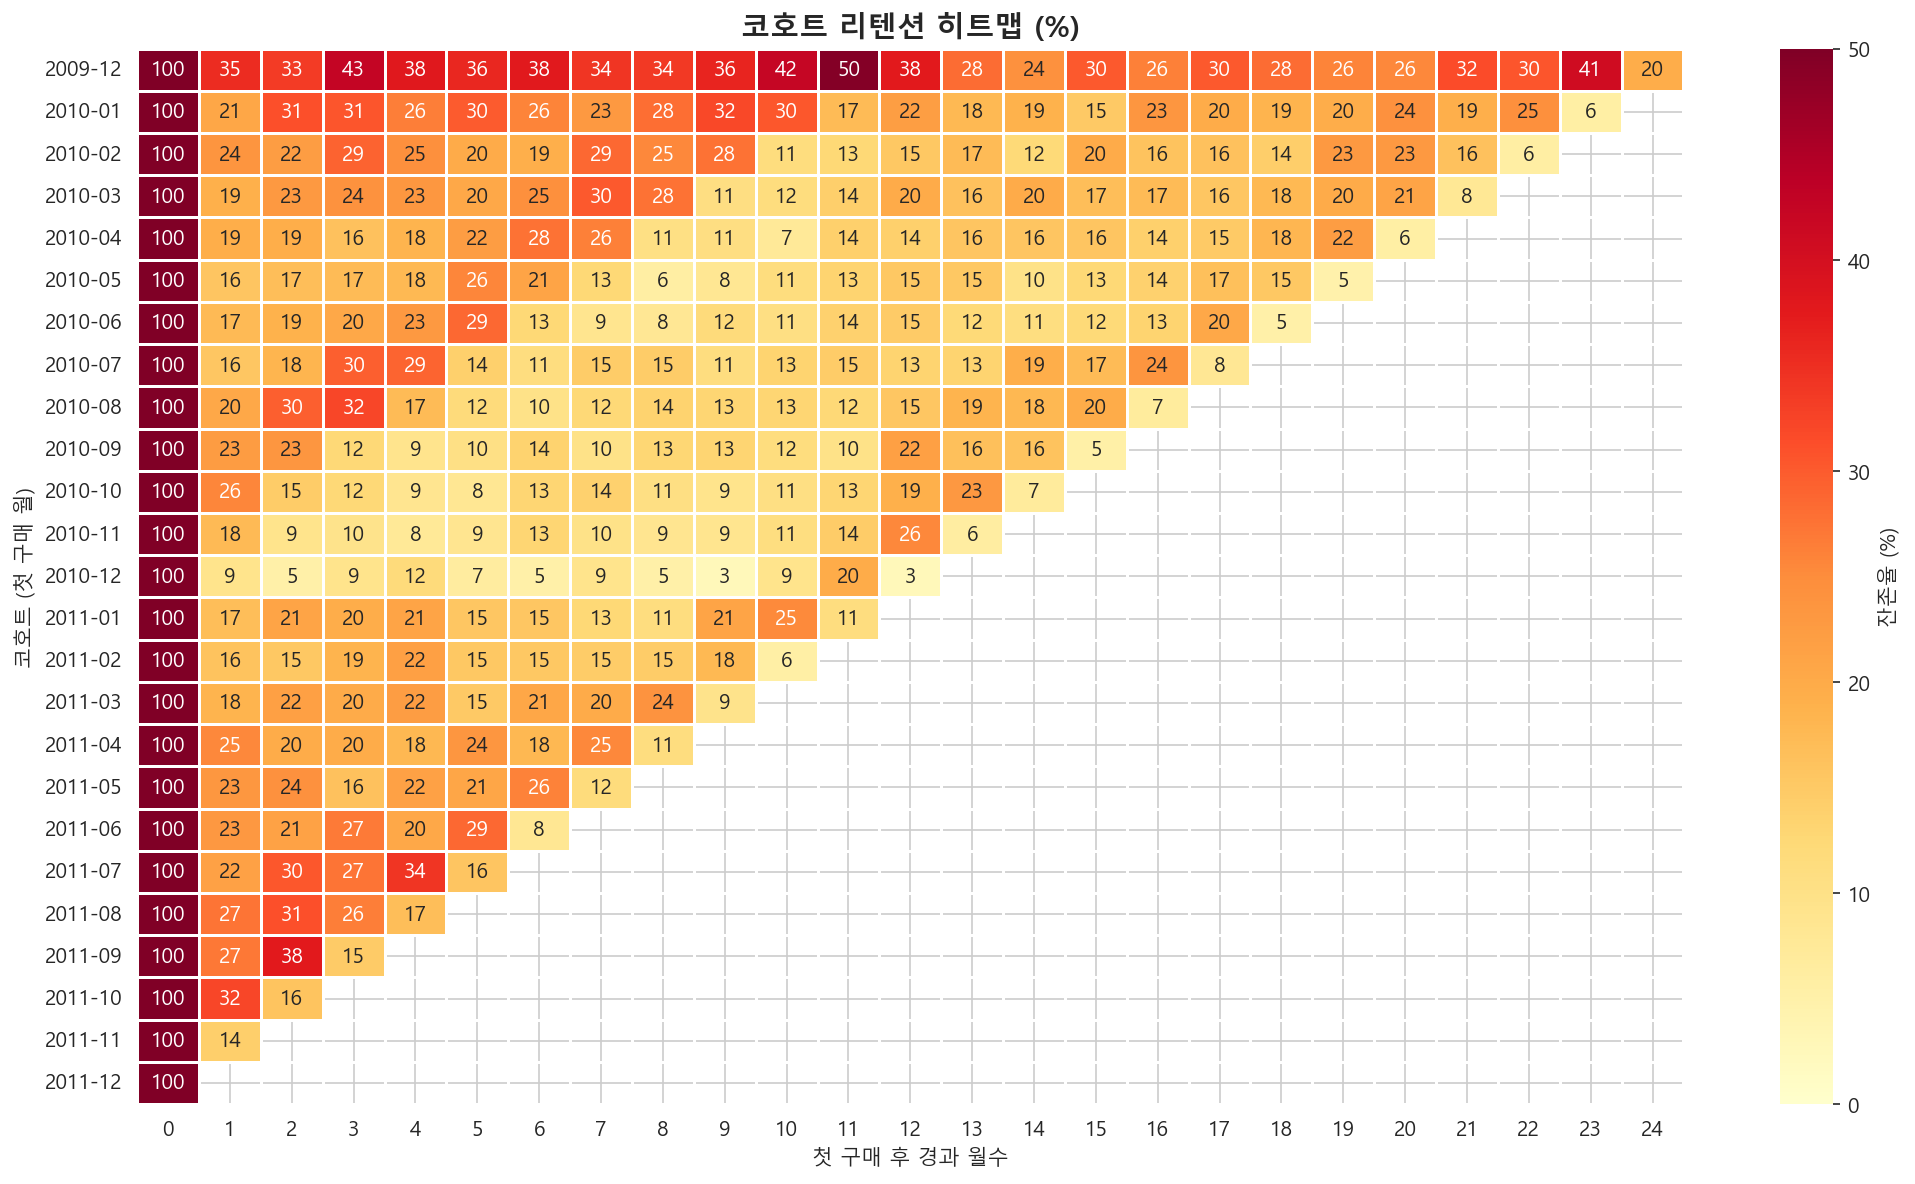

In [13]:
fig, ax = plt.subplots(figsize=(14, 8))

retention_display = retention.copy()
retention_display.index = retention_display.index.strftime('%Y-%m')

sns.heatmap(retention_display, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, vmin=0, vmax=50,
            cbar_kws={'label': '잔존율 (%)'})

ax.set_title('코호트 리텐션 히트맵 (%)', fontsize=14, fontweight='bold')
ax.set_xlabel('첫 구매 후 경과 월수')
ax.set_ylabel('코호트 (첫 구매 월)')
plt.tight_layout()
plt.savefig(IMAGES_DIR / '07_cohort_heatmap.png', bbox_inches='tight')
plt.show()

### 4.2 코호트 크기 (월별 신규 고객)

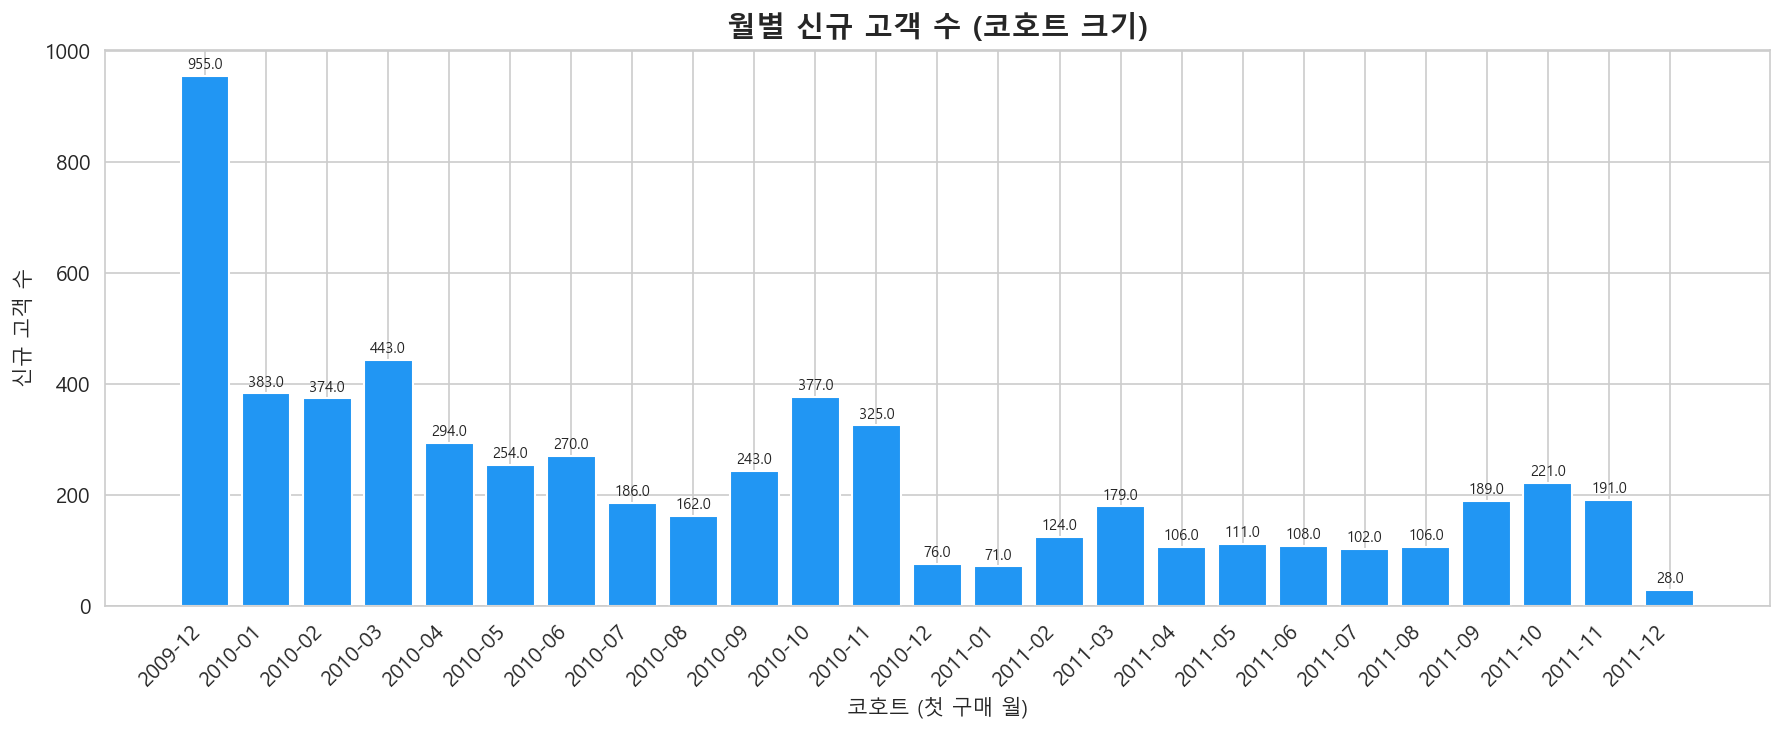

In [14]:
fig, ax = plt.subplots(figsize=(12, 5))

cohort_labels = cohort_size.index.strftime('%Y-%m')
bars = ax.bar(cohort_labels, cohort_size.values, color='#2196F3', edgecolor='white')
ax.set_title('월별 신규 고객 수 (코호트 크기)', fontsize=14, fontweight='bold')
ax.set_xlabel('코호트 (첫 구매 월)')
ax.set_ylabel('신규 고객 수')
plt.xticks(rotation=45, ha='right')

for bar, val in zip(bars, cohort_size.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
            f'{val}', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig(IMAGES_DIR / '08_cohort_size.png', bbox_inches='tight')
plt.show()

### 4.3 평균 리텐션 곡선

> 모든 코호트의 잔존율을 평균 낸 곡선이다.  
> "평균적으로 첫 구매 후 N개월이 지나면 몇 %가 남는가?" 를 한눈에 보여준다.

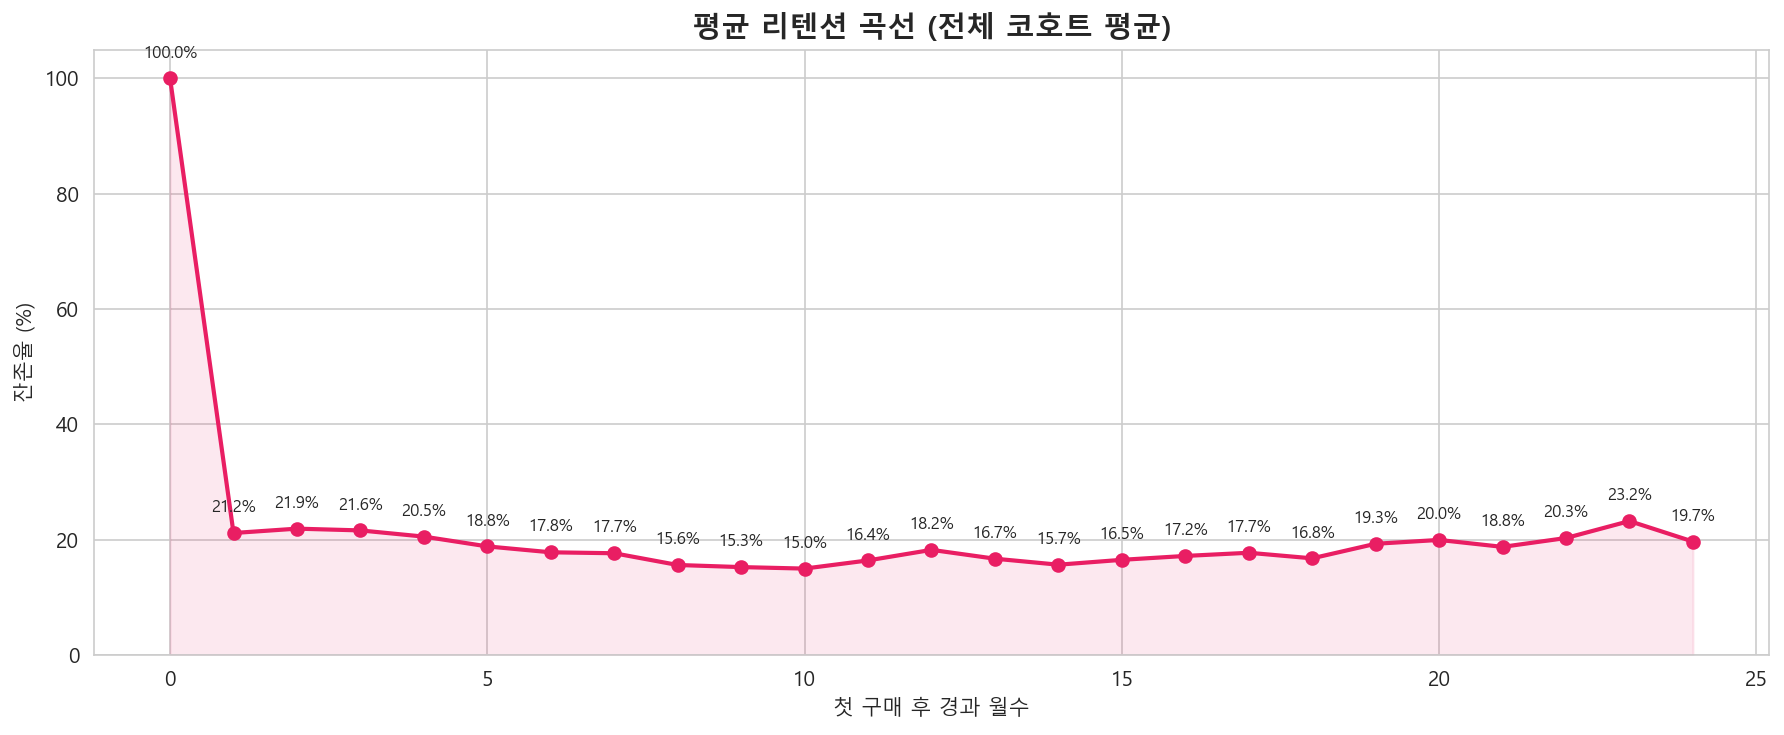

1개월 후 평균 잔존율: 21.2%
3개월 후 평균 잔존율: 21.6%
6개월 후 평균 잔존율: 17.8%
12개월 후 평균 잔존율: 18.2%


In [15]:
avg_retention = retention.mean()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(avg_retention.index, avg_retention.values, marker='o', linewidth=2, color='#E91E63')
ax.fill_between(avg_retention.index, avg_retention.values, alpha=0.1, color='#E91E63')

for i, (x, y) in enumerate(zip(avg_retention.index, avg_retention.values)):
    ax.annotate(f'{y:.1f}%', (x, y), textcoords='offset points',
                xytext=(0, 10), ha='center', fontsize=8)

ax.set_title('평균 리텐션 곡선 (전체 코호트 평균)', fontsize=14, fontweight='bold')
ax.set_xlabel('첫 구매 후 경과 월수')
ax.set_ylabel('잔존율 (%)')
ax.set_ylim(0, 105)
plt.tight_layout()
plt.savefig(IMAGES_DIR / '09_avg_retention.png', bbox_inches='tight')
plt.show()

print(f'1개월 후 평균 잔존율: {avg_retention.iloc[1]:.1f}%')
print(f'3개월 후 평균 잔존율: {avg_retention.iloc[3]:.1f}%' if len(avg_retention) > 3 else '')
print(f'6개월 후 평균 잔존율: {avg_retention.iloc[6]:.1f}%' if len(avg_retention) > 6 else '')
print(f'12개월 후 평균 잔존율: {avg_retention.iloc[12]:.1f}%' if len(avg_retention) > 12 else '')

---
## 5. AARRR 해적 지표

> **AARRR이 뭔데?**  
> 스타트업/서비스의 성장을 5단계로 나눠서 보는 프레임워크다.  
> 발음이 해적 소리("아아르르르") 같다고 해서 **"해적 지표(Pirate Metrics)"** 라고도 부른다.  
> 2007년 Dave McClure가 만들었고, 지금도 스타트업/그로스해킹에서 가장 널리 쓰이는 분석 틀이다.
>
> | 단계 | 영어 | 쉽게 말하면 | 핵심 질문 |
> |---|---|---|---|
> | **A**cquisition | 획득 | 고객이 처음 오는 것 | 새 고객이 매달 몇 명 오나? |
> | **A**ctivation | 활성화 | 처음 와서 "아 좋다" 하는 순간 | 첫 구매 경험이 괜찮았나? |
> | **R**etention | 유지 | 다시 돌아오는 것 | 한 번 산 사람이 또 사나? |
> | **R**evenue | 수익 | 돈을 내는 것 | 고객당 얼마를 쓰나? |
> | **R**eferral | 추천 | 친구한테 알려주는 것 | 다른 사람한테 추천하나? |
>
> **왜 하는 건데?**  
> 고객의 여정을 단계별로 쪼개서 보면, **"우리 서비스가 어느 단계에서 약한지"** 를 정확히 진단할 수 있다.  
> 예를 들어 Acquisition은 잘 되는데 Retention이 낮으면 → "고객은 많이 오지만 다시 안 오는 거니까 재구매 유도에 집중하자"  
> 이런 식으로 한정된 자원을 어디에 쓸지 결정하는 데 쓴다.

### 5.1 Acquisition (획득) — 월별 신규 고객 수

> 매달 새로 들어온 고객이 몇 명인지 본다.  
> 이 숫자가 늘어나면 사업이 성장하고 있다는 신호이고, 줄어들면 마케팅이 필요하다는 신호다.

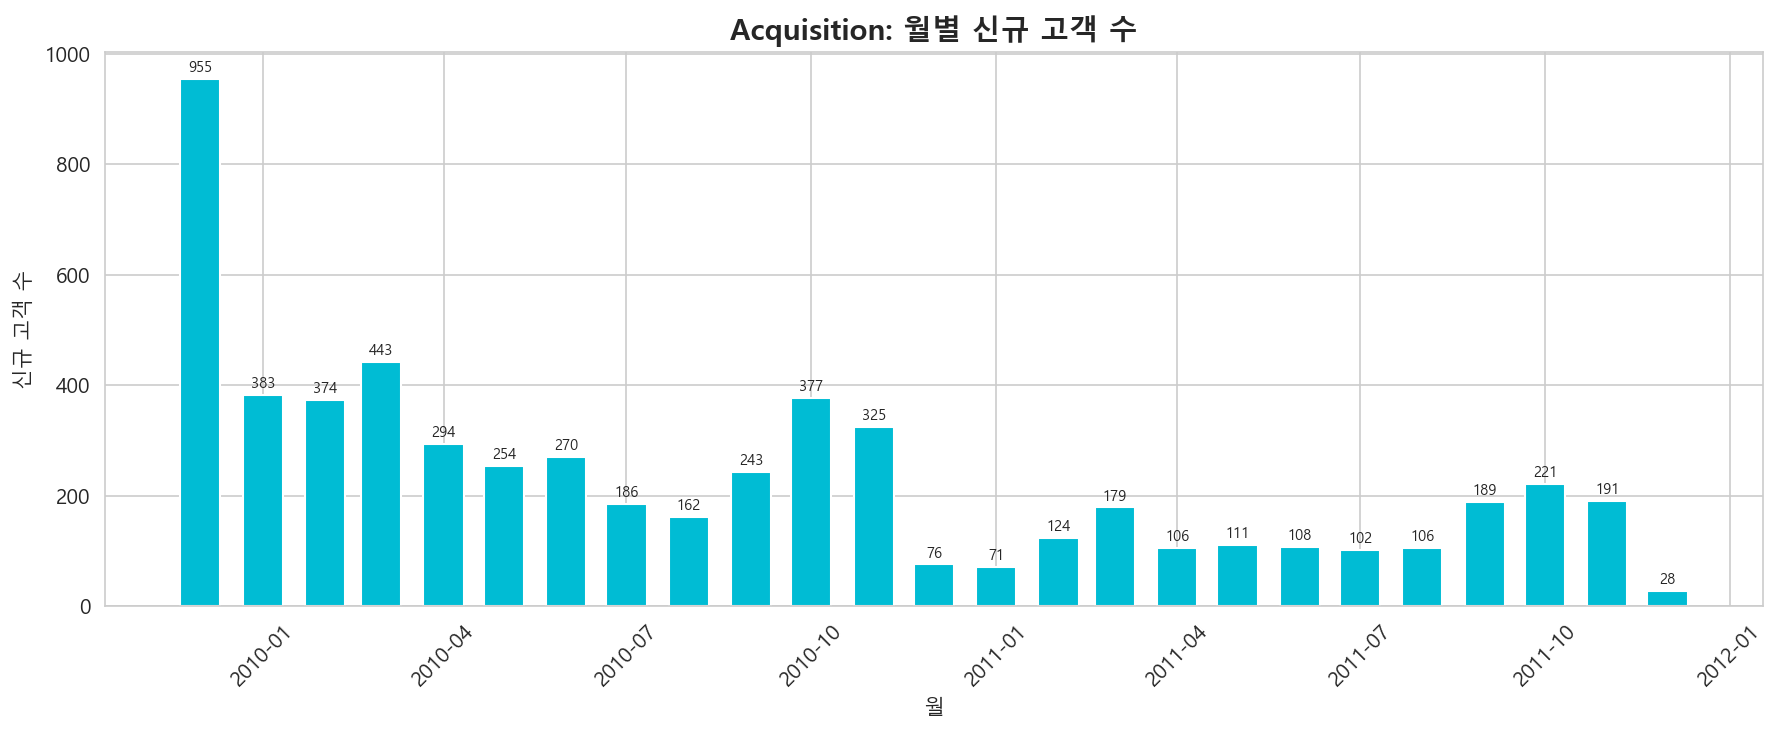

전체 기간 신규 고객 합계: 5,878명
월 평균 신규 고객: 235명


In [16]:
first_purchase = df.groupby('Customer ID')['InvoiceYearMonth'].min().reset_index()
first_purchase.columns = ['Customer ID', 'FirstPurchaseMonth']
new_customers = first_purchase.groupby('FirstPurchaseMonth').size()

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(new_customers.index, new_customers.values, color='#00BCD4', edgecolor='white', width=20)
ax.set_title('Acquisition: 월별 신규 고객 수', fontsize=14, fontweight='bold')
ax.set_xlabel('월')
ax.set_ylabel('신규 고객 수')
plt.xticks(rotation=45)

for bar, val in zip(bars, new_customers.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
            f'{val}', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig(IMAGES_DIR / '10_acquisition.png', bbox_inches='tight')
plt.show()

print(f'전체 기간 신규 고객 합계: {len(first_purchase):,}명')
print(f'월 평균 신규 고객: {new_customers.mean():.0f}명')

### 5.2 Activation (활성화) — 첫 주문의 질

> 고객이 처음 왔을 때의 구매 경험을 본다.  
> 첫 주문 금액이 크고, 그 후 재구매로 이어지면 "활성화가 잘 됐다"고 판단한다.

In [17]:
# 각 고객의 첫 번째 주문 찾기
first_invoice = df.sort_values('InvoiceDate').groupby('Customer ID').first().reset_index()

# 첫 주문에 포함된 모든 상품 가져오기
first_orders = df.merge(
    first_invoice[['Customer ID', 'Invoice']],
    on=['Customer ID', 'Invoice'],
    how='inner'
)

first_order_revenue = first_orders.groupby('Customer ID')['Revenue'].sum()
first_order_items = first_orders.groupby('Customer ID')['Quantity'].sum()

print('=== Activation 지표: 첫 주문의 질 ===')
print(f'첫 주문 평균 금액: £{first_order_revenue.mean():.2f}')
print(f'첫 주문 중앙값 금액: £{first_order_revenue.median():.2f}')
print(f'첫 주문 평균 상품 수: {first_order_items.mean():.1f}개')
print(f'첫 주문 중앙값 상품 수: {first_order_items.median():.0f}개')

# 첫 구매 후 재구매한 비율
repeat_rate = (cust['n_orders'] >= 2).mean()
print(f'\n첫 구매 → 재구매 전환율: {repeat_rate:.1%}')
print(f'→ 해석: 100명이 처음 사면 그중 {repeat_rate*100:.0f}명이 다시 산다.')

=== Activation 지표: 첫 주문의 질 ===
첫 주문 평균 금액: £416.30
첫 주문 중앙값 금액: £298.31
첫 주문 평균 상품 수: 262.0개
첫 주문 중앙값 상품 수: 156개

첫 구매 → 재구매 전환율: 72.4%
→ 해석: 100명이 처음 사면 그중 72명이 다시 산다.


### 5.3 Retention (유지) — 30/60/90일 재구매율

> 첫 구매 후 30일, 60일, 90일 안에 다시 사는 고객이 몇 %인지 본다.  
> 재구매까지 걸리는 시간이 짧을수록, 비율이 높을수록 좋다.

In [18]:
# 고객별 첫 구매일과 마지막 구매일
customer_dates = df.groupby('Customer ID')['InvoiceDate'].agg(['min', 'max']).reset_index()
customer_dates.columns = ['Customer ID', 'first_purchase', 'last_purchase']

# 두 번째 주문 날짜 구하기
orders_sorted = df.groupby(['Customer ID', 'Invoice'])['InvoiceDate'].min().reset_index()
orders_sorted = orders_sorted.sort_values(['Customer ID', 'InvoiceDate'])
orders_sorted['order_rank'] = orders_sorted.groupby('Customer ID').cumcount() + 1

second_purchase = orders_sorted[orders_sorted['order_rank'] == 2][['Customer ID', 'InvoiceDate']]
second_purchase.columns = ['Customer ID', 'second_purchase_date']

retention_calc = customer_dates.merge(second_purchase, on='Customer ID', how='left')
retention_calc['days_to_second'] = (retention_calc['second_purchase_date'] - retention_calc['first_purchase']).dt.days

total_customers = len(retention_calc)
has_second = retention_calc['days_to_second'].notna()

print('=== Retention 지표: N일 이내 재구매율 ===')
for days in [30, 60, 90, 180, 365]:
    count = ((retention_calc['days_to_second'] <= days) & has_second).sum()
    print(f'  {days:>3d}일 이내 재구매: {count:,}명 ({count / total_customers:.1%})')

print(f'\n→ 해석: 30일 안에 다시 사는 사람은 {((retention_calc["days_to_second"] <= 30) & has_second).sum() / total_customers:.1%} 뿐이다.')
print(f'  첫 달이 가장 중요한 이탈 구간이라는 뜻이다.')

=== Retention 지표: N일 이내 재구매율 ===
   30일 이내 재구매: 1,388명 (23.6%)
   60일 이내 재구매: 2,243명 (38.2%)
   90일 이내 재구매: 2,745명 (46.7%)
  180일 이내 재구매: 3,541명 (60.2%)
  365일 이내 재구매: 4,085명 (69.5%)

→ 해석: 30일 안에 다시 사는 사람은 23.6% 뿐이다.
  첫 달이 가장 중요한 이탈 구간이라는 뜻이다.


### 5.4 Revenue (수익) — ARPU & AOV 추이

> - **ARPU** (Average Revenue Per User): 고객 1명당 평균 매출. "한 사람이 평균 얼마를 쓰나?"
> - **AOV** (Average Order Value): 주문 1건당 평균 금액. "한 번 살 때 평균 얼마를 쓰나?"
>
> 이 두 지표가 올라가면 같은 고객 수로도 매출이 늘어난다는 뜻이다.

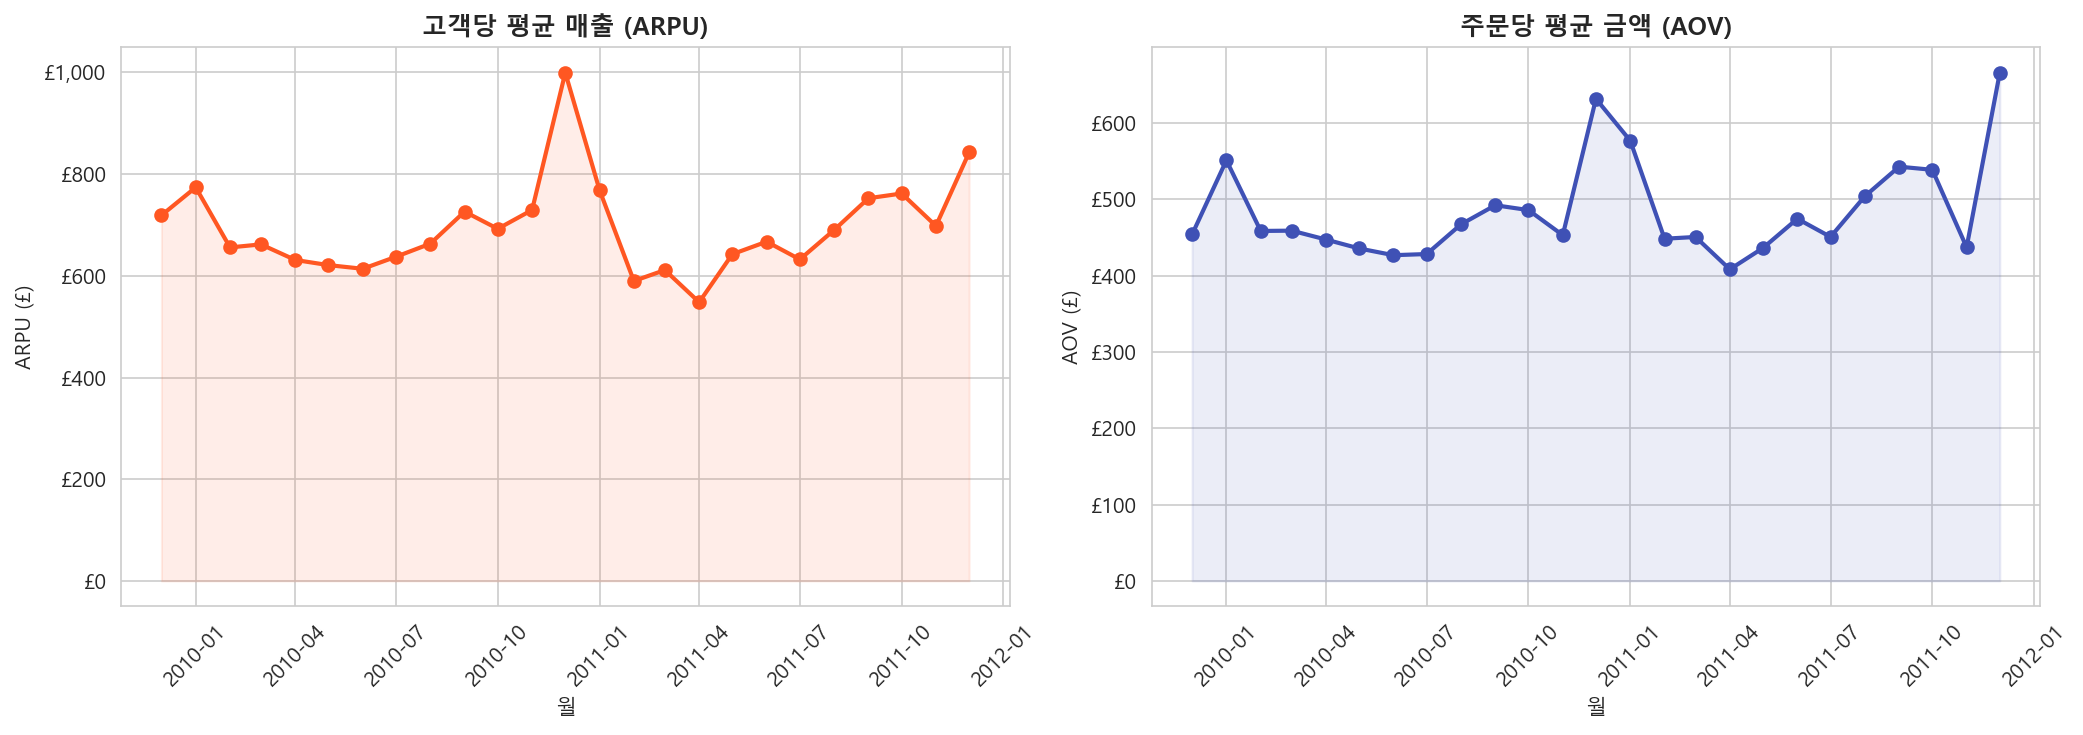

전체 기간 ARPU: £3,018.62
전체 기간 AOV: £479.95


In [19]:
monthly_stats = df.groupby('InvoiceYearMonth').agg(
    total_revenue=('Revenue', 'sum'),
    n_customers=('Customer ID', 'nunique'),
    n_orders=('Invoice', 'nunique')
).reset_index()

monthly_stats['ARPU'] = monthly_stats['total_revenue'] / monthly_stats['n_customers']
monthly_stats['AOV'] = monthly_stats['total_revenue'] / monthly_stats['n_orders']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ARPU
ax1.plot(monthly_stats['InvoiceYearMonth'], monthly_stats['ARPU'], marker='o', color='#FF5722', linewidth=2)
ax1.fill_between(monthly_stats['InvoiceYearMonth'], monthly_stats['ARPU'], alpha=0.1, color='#FF5722')
ax1.set_title('고객당 평균 매출 (ARPU)', fontsize=12, fontweight='bold')
ax1.set_xlabel('월')
ax1.set_ylabel('ARPU (£)')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
ax1.tick_params(axis='x', rotation=45)

# AOV
ax2.plot(monthly_stats['InvoiceYearMonth'], monthly_stats['AOV'], marker='o', color='#3F51B5', linewidth=2)
ax2.fill_between(monthly_stats['InvoiceYearMonth'], monthly_stats['AOV'], alpha=0.1, color='#3F51B5')
ax2.set_title('주문당 평균 금액 (AOV)', fontsize=12, fontweight='bold')
ax2.set_xlabel('월')
ax2.set_ylabel('AOV (£)')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(IMAGES_DIR / '11_arpu_aov.png', bbox_inches='tight')
plt.show()

print(f'전체 기간 ARPU: £{df["Revenue"].sum() / df["Customer ID"].nunique():,.2f}')
print(f'전체 기간 AOV: £{df["Revenue"].sum() / df["Invoice"].nunique():,.2f}')

### 5.5 Referral (추천) — 한계점

> **측정 불가**: 이 데이터셋에는 추천/유입 채널 정보가 없다.  
> 따라서 Referral 지표를 직접 측정할 수 없다.  
> 대신 고객이 어느 나라에서 오는지를 참고용으로 확인한다.  
> 다양한 국가에서 고객이 오면 입소문이 퍼지고 있을 가능성이 있다.

In [20]:
country_customers = df.groupby('Country')['Customer ID'].nunique().sort_values(ascending=False)
print(f'고객이 있는 국가 수: {len(country_customers)}개국')
print(f'\n국가별 고객 수 Top 10:')
for country, count in country_customers.head(10).items():
    print(f'  {country:30s}: {count:,}명')

고객이 있는 국가 수: 41개국

국가별 고객 수 Top 10:
  United Kingdom                : 5,350명
  Germany                       : 107명
  France                        : 95명
  Spain                         : 41명
  Belgium                       : 29명
  Portugal                      : 24명
  Switzerland                   : 22명
  Netherlands                   : 22명
  Sweden                        : 19명
  Italy                         : 17명


---
## 6. 핵심 인사이트 & 제안

> 위에서 분석한 내용을 종합하여, 실제 비즈니스에서 "그래서 뭘 해야 하는데?"에 답하는 부분이다.  
> 데이터 분석의 목적은 숫자를 나열하는 것이 아니라 **행동으로 이어지는 제안**을 하는 것이다.

In [21]:
# 핵심 지표 수집
total_customers = df['Customer ID'].nunique()
total_revenue = df['Revenue'].sum()
repeat_buyer_rate = (cust['n_orders'] >= 2).mean()
one_time_pct = (cust['n_orders'] == 1).mean()
uk_share = country_revenue['United Kingdom'] / country_revenue.sum()
month1_retention = avg_retention.iloc[1] if len(avg_retention) > 1 else 0
top_pct_80_rev = pct_80

print('=' * 70)
print('핵심 인사이트')
print('=' * 70)

print(f'''
1. 매출 집중 리스크가 높다
   상위 {top_pct_80_rev:.0f}%의 고객이 전체 매출의 80%를 만든다 (총 £{total_revenue:,.0f}).
   → 소수 고객에게 과도하게 의존하고 있어, 이들이 이탈하면 매출에 큰 타격이 온다.

2. 1회성 구매 고객 문제
   전체 고객의 {one_time_pct:.1%}가 딱 1번만 사고 다시 오지 않는다.
   재구매율은 {repeat_buyer_rate:.1%} — 개선의 여지가 크다.

3. 첫 달 이탈이 가장 심하다
   평균적으로 첫 구매 1개월 후 잔존율이 {month1_retention:.1f}%에 불과하다.
   → 첫 구매 직후가 고객을 잡을 가장 중요한 타이밍이다.

4. 영국 의존도가 너무 높다
   영국이 전체 매출의 {uk_share:.1%}를 차지한다.
   → 해외 시장 확대가 성장을 위한 핵심 기회이다.

5. 강한 계절 패턴
   매출이 Q4(9~11월)에 급증하며 연말 쇼핑 시즌에 의존적이다.
   → 연말에 들어온 고객이 1월 이후에도 남도록 잡는 것이 핵심이다.
''')

print('=' * 70)
print('비즈니스 제안')
print('=' * 70)

print(f'''
1. 첫 달 이탈을 줄여라
   첫 구매 후 7일, 14일, 30일에 맞춤형 상품 추천 이메일을 보내
   1회성 구매 고객을 재구매 고객으로 전환시켜야 한다.

2. 고가치 고객에게 충성 프로그램을 제공하라
   매출의 80%를 만들어내는 상위 {top_pct_80_rev:.0f}% 고객을 위한
   등급별 리워드 프로그램으로 이탈을 방지하고 LTV를 높여야 한다.

3. 해외 시장을 개척하라
   비UK 상위 시장(네덜란드, 아일랜드, 독일, 프랑스)에
   현지화된 마케팅과 무료배송 기준을 도입하라.

4. 1월에 재활성화 캠페인을 실시하라
   연말 쇼핑 시즌에 들어온 신규 고객들이 1월에 이탈하지 않도록
   타겟 캠페인(할인 쿠폰, 재구매 유도)을 집중 실행하라.
''')

핵심 인사이트

1. 매출 집중 리스크가 높다
   상위 23%의 고객이 전체 매출의 80%를 만든다 (총 £17,743,429).
   → 소수 고객에게 과도하게 의존하고 있어, 이들이 이탈하면 매출에 큰 타격이 온다.

2. 1회성 구매 고객 문제
   전체 고객의 27.6%가 딱 1번만 사고 다시 오지 않는다.
   재구매율은 72.4% — 개선의 여지가 크다.

3. 첫 달 이탈이 가장 심하다
   평균적으로 첫 구매 1개월 후 잔존율이 21.2%에 불과하다.
   → 첫 구매 직후가 고객을 잡을 가장 중요한 타이밍이다.

4. 영국 의존도가 너무 높다
   영국이 전체 매출의 83.0%를 차지한다.
   → 해외 시장 확대가 성장을 위한 핵심 기회이다.

5. 강한 계절 패턴
   매출이 Q4(9~11월)에 급증하며 연말 쇼핑 시즌에 의존적이다.
   → 연말에 들어온 고객이 1월 이후에도 남도록 잡는 것이 핵심이다.

비즈니스 제안

1. 첫 달 이탈을 줄여라
   첫 구매 후 7일, 14일, 30일에 맞춤형 상품 추천 이메일을 보내
   1회성 구매 고객을 재구매 고객으로 전환시켜야 한다.

2. 고가치 고객에게 충성 프로그램을 제공하라
   매출의 80%를 만들어내는 상위 23% 고객을 위한
   등급별 리워드 프로그램으로 이탈을 방지하고 LTV를 높여야 한다.

3. 해외 시장을 개척하라
   비UK 상위 시장(네덜란드, 아일랜드, 독일, 프랑스)에
   현지화된 마케팅과 무료배송 기준을 도입하라.

4. 1월에 재활성화 캠페인을 실시하라
   연말 쇼핑 시즌에 들어온 신규 고객들이 1월에 이탈하지 않도록
   타겟 캠페인(할인 쿠폰, 재구매 유도)을 집중 실행하라.



### 요약 대시보드

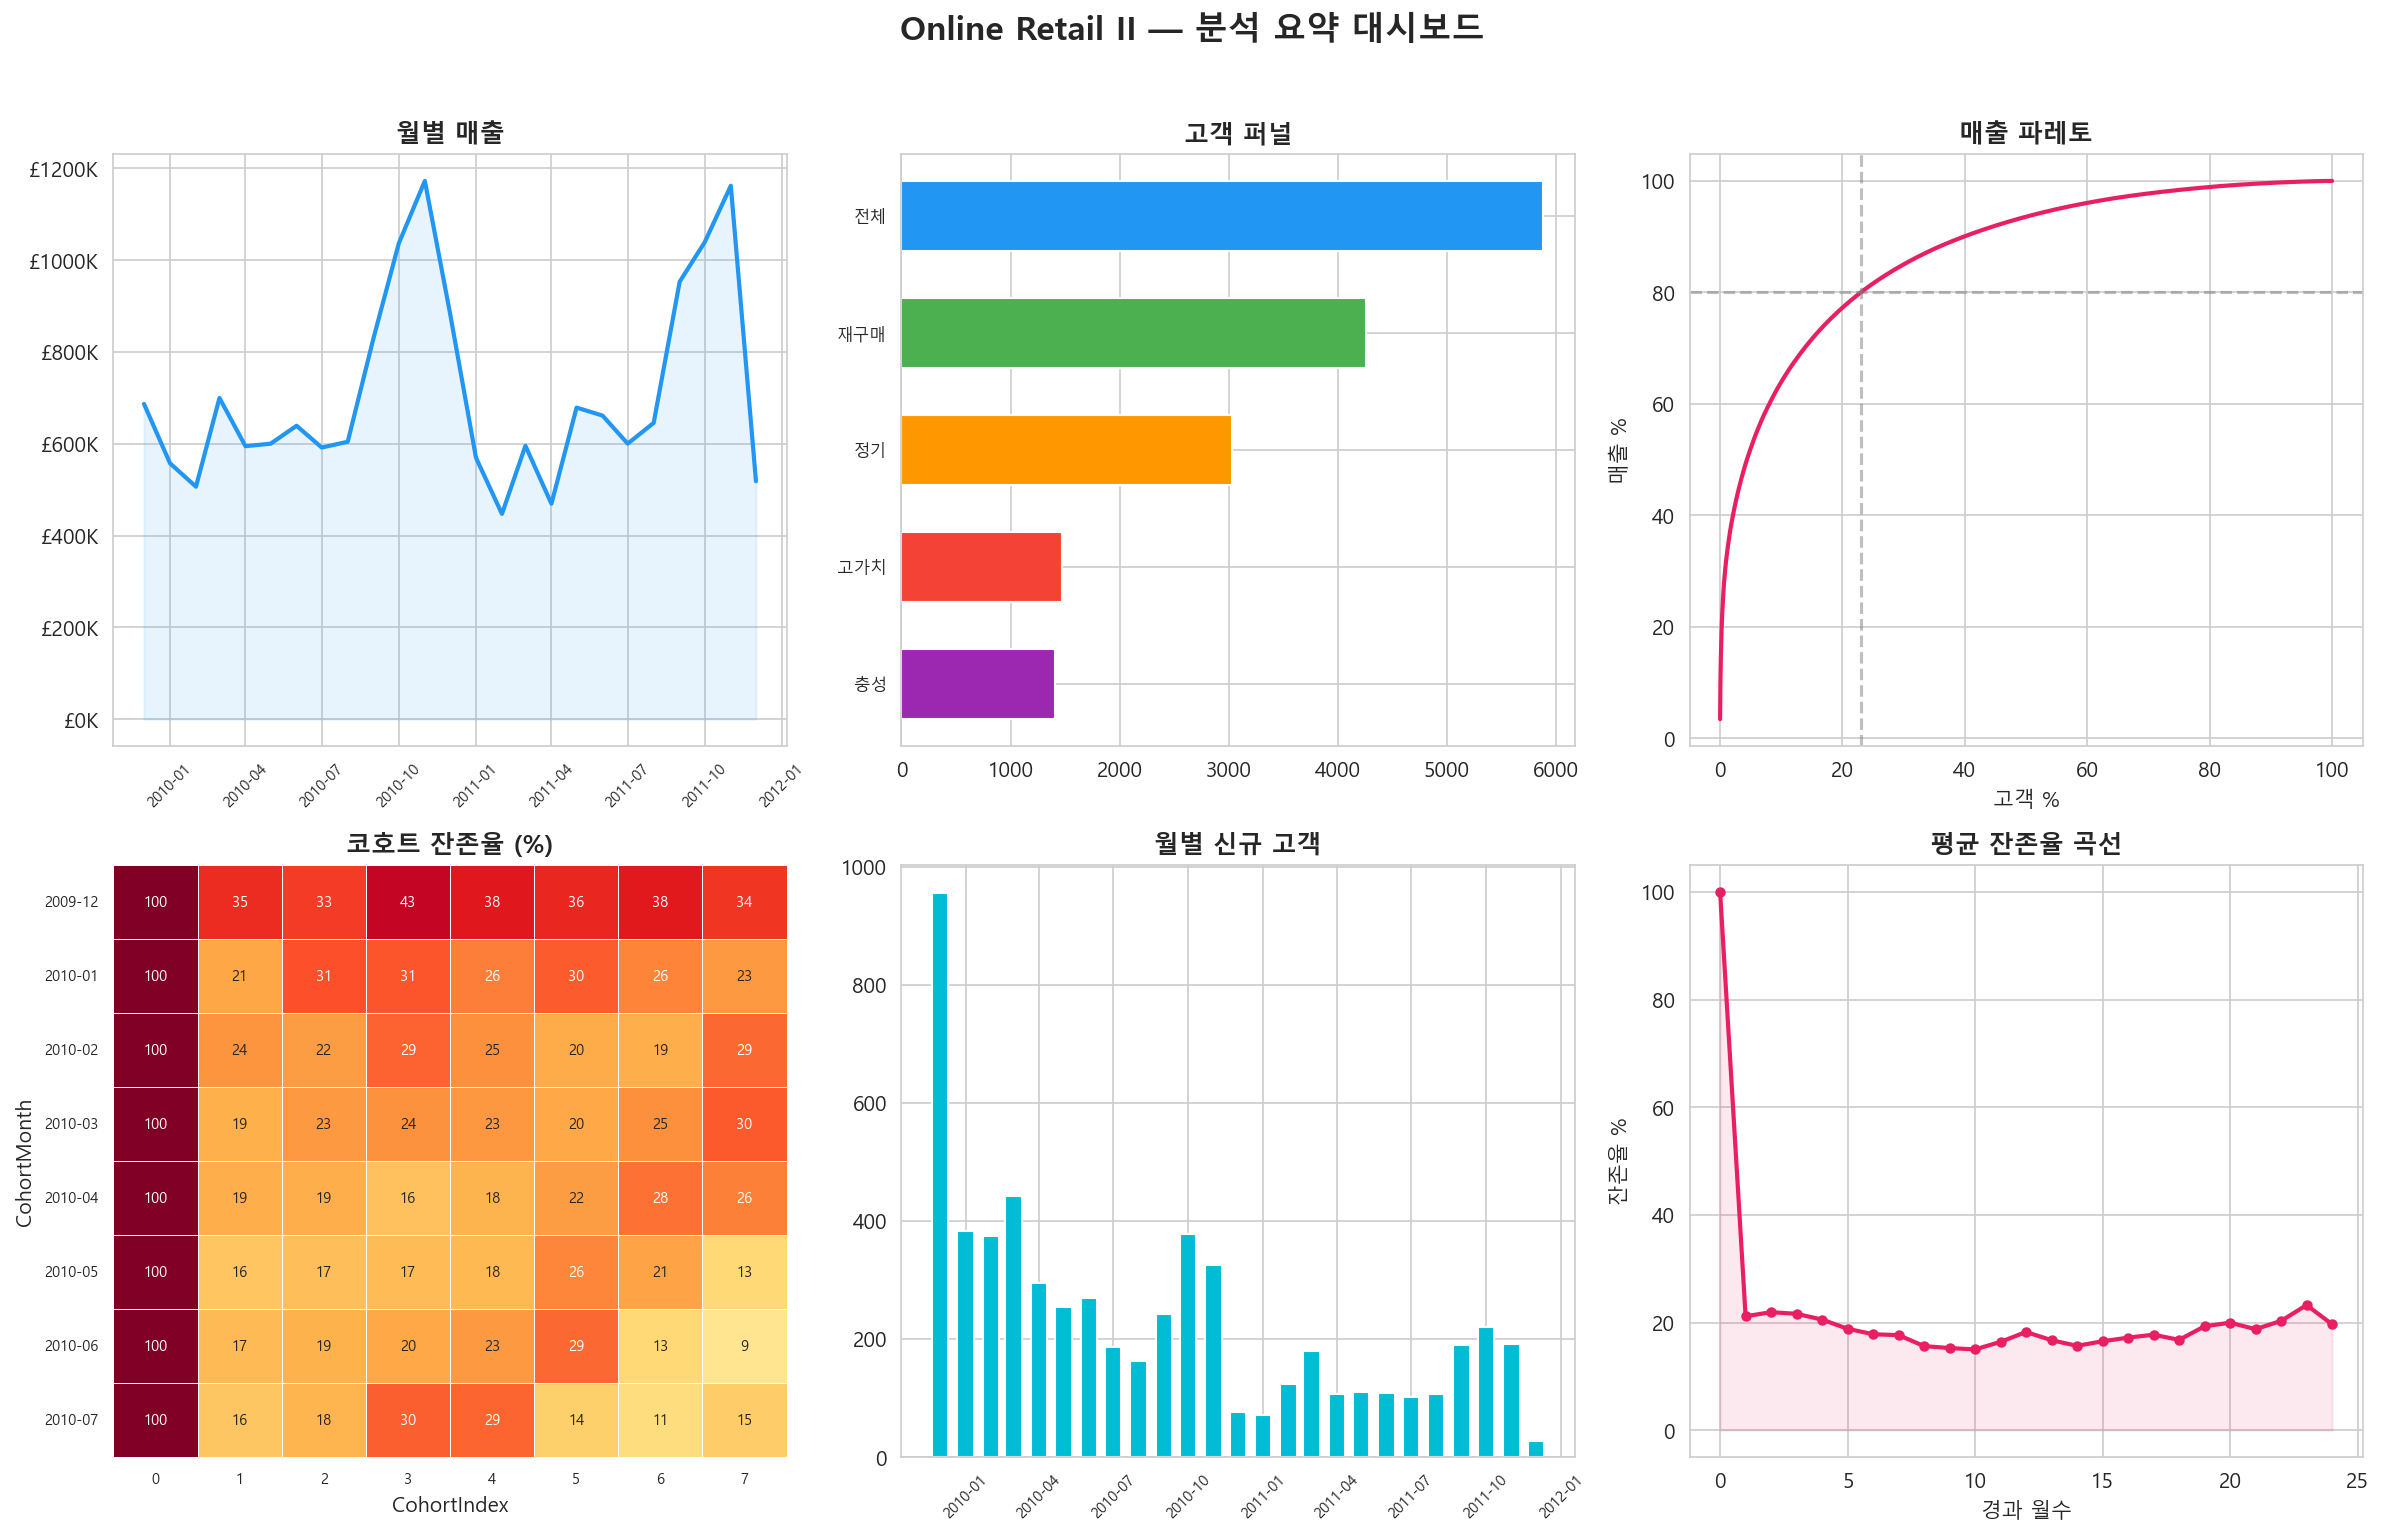

In [22]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Online Retail II — 분석 요약 대시보드', fontsize=16, fontweight='bold', y=1.02)

# 1. 월별 매출
ax = axes[0, 0]
ax.plot(monthly_revenue.index, monthly_revenue.values, color='#2196F3', linewidth=2)
ax.fill_between(monthly_revenue.index, monthly_revenue.values, alpha=0.1, color='#2196F3')
ax.set_title('월별 매출', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))
ax.tick_params(axis='x', rotation=45, labelsize=7)

# 2. 고객 퍼널
ax = axes[0, 1]
colors_f = ['#2196F3', '#4CAF50', '#FF9800', '#F44336', '#9C27B0']
y_f = range(len(funnel_df) - 1, -1, -1)
ax.barh(y_f, funnel_df['고객 수'], color=colors_f, height=0.6)
ax.set_yticks(y_f)
short_labels = ['전체', '재구매', '정기', '고가치', '충성']
ax.set_yticklabels(short_labels, fontsize=8)
ax.set_title('고객 퍼널', fontweight='bold')

# 3. 파레토
ax = axes[0, 2]
ax.plot(customer_pct, cumulative_pct.values, color='#E91E63', linewidth=2)
ax.axhline(80, color='gray', linestyle='--', alpha=0.5)
ax.axvline(pct_80, color='gray', linestyle='--', alpha=0.5)
ax.set_title('매출 파레토', fontweight='bold')
ax.set_xlabel('고객 %')
ax.set_ylabel('매출 %')

# 4. 코호트 히트맵 (축소)
ax = axes[1, 0]
retention_small = retention_display.iloc[:8, :8]
sns.heatmap(retention_small, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.3, ax=ax, vmin=0, vmax=50, cbar=False,
            annot_kws={'size': 7})
ax.set_title('코호트 잔존율 (%)', fontweight='bold')
ax.tick_params(axis='both', labelsize=7)

# 5. 신규 고객
ax = axes[1, 1]
ax.bar(new_customers.index, new_customers.values, color='#00BCD4', width=20)
ax.set_title('월별 신규 고객', fontweight='bold')
ax.tick_params(axis='x', rotation=45, labelsize=7)

# 6. 평균 잔존율 곡선
ax = axes[1, 2]
ax.plot(avg_retention.index, avg_retention.values, marker='o', color='#E91E63', linewidth=2, markersize=4)
ax.fill_between(avg_retention.index, avg_retention.values, alpha=0.1, color='#E91E63')
ax.set_title('평균 잔존율 곡선', fontweight='bold')
ax.set_xlabel('경과 월수')
ax.set_ylabel('잔존율 %')

plt.tight_layout()
plt.savefig(IMAGES_DIR / '12_summary_dashboard.png', bbox_inches='tight')
plt.show()